## CPU Scaling

### Thread

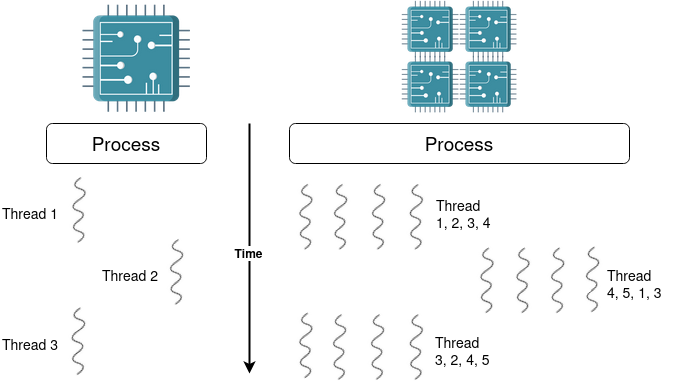

In [1]:
import threading

x = []

def append_two(l):
    l.append(2)

threading.Thread(target=append_two, args=(x,)).start()
x.append(1)

print(x)

[2, 1]


In [2]:
import random
import threading

results = []

def compute():
    results.append(sum(
        [random.randint(1, 100) for i in range(1000000)]))

workers = [threading.Thread(target=compute) for x in range(8)]
for worker in workers:
    worker.start()
for worker in workers:
    worker.join()
print("Results: %s" % results)

Results: [50468027, 50515219, 50482295, 50496625, 50506687, 50541192, 50502373, 50497106]


### processes

In [3]:
import random
import multiprocessing

def compute(results):
    results.append(sum(
        [random.randint(1, 100) for i in range(1000000)]))

if __name__ == "__main__":
    with multiprocessing.Manager() as manager:
        results = manager.list()
        workers = [multiprocessing.Process(target=compute, args=(results,))
                   for x in range(8)]
        for worker in workers:
            worker.start()
        for worker in workers:
            worker.join()
        print("Results: %s" % results)


Results: [50512841, 50437127, 50510082, 50564597, 50460277, 50520868, 50470284, 50488221]


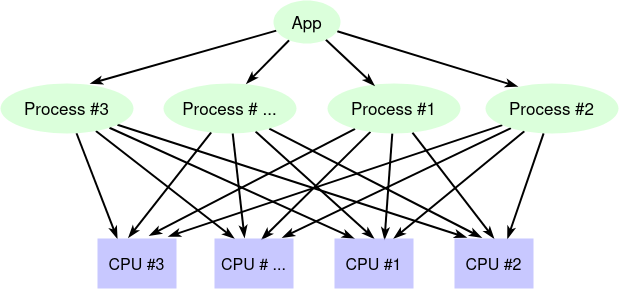

In [ ]:
import multiprocessing
import random

def compute(n):
    return sum(
        [random.randint(1, 100) for i in range(1000000)])

if __name__ == "__main__":
    # Start 8 workers
    pool = multiprocessing.Pool(processes=8)
    print("Results: %s" % pool.map(compute, range(8)))


Results: [50469652, 50442202, 50553623, 50528962, 50522562, 50537940, 50527639, 50522228]


Process ForkPoolWorker-13:
Process ForkPoolWorker-12:
Process ForkPoolWorker-11:
Process ForkPoolWorker-15:
Process ForkPoolWorker-10:
Process ForkPoolWorker-17:
Process ForkPoolWorker-16:
Process ForkPoolWorker-14:
  File "/usr/lib/python3.12/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/usr/lib/python3.12/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/usr/lib/python3.12/multiprocessing/process.py", line 314, in _bootstrap
    self.run()
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 216, in recv_bytes
    buf = self._recv_bytes(maxlength)
          ^^^^^^^^^^^^^^^^^^^^^^^^^^^
KeyboardInterrupt
  File "/usr/lib/python3.12/multiprocessing/connection.py", line 395, in _recv
    chunk = read(handle, remaining)
            ^^^^^^^^^^^^^^^^^^^^^^^
KeyboardInterrupt
KeyboardInterrupt
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent cal

### Futures

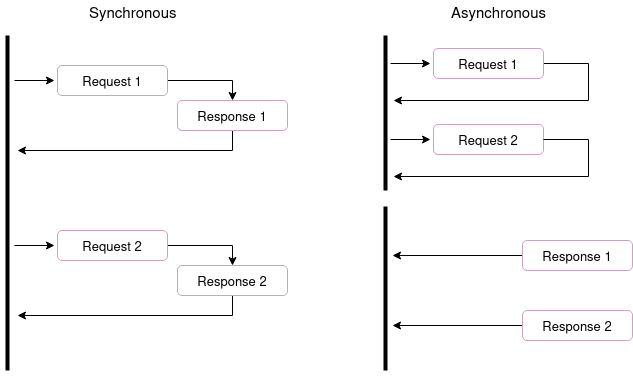

In [5]:
from concurrent import futures
import random

def compute():
    return sum(
        [random.randint(1, 100) for i in range(1000000)])

with futures.ThreadPoolExecutor(max_workers=8) as executor:
    futs = [executor.submit(compute) for _ in range(8)]

results = [f.result() for f in futs]

print("Results: %s" % results)

Results: [50470412, 50472179, 50503885, 50493765, 50527710, 50504066, 50512977, 50510465]


In [6]:
from concurrent import futures
import random

def compute():
    return sum(
        [random.randint(1, 100) for i in range(1000000)])

if __name__ == "__main__":
    with futures.ProcessPoolExecutor() as executor:
        futs = [executor.submit(compute) for _ in range(8)]

    results = [f.result() for f in futs]

    print("Results: %s" % results)

Results: [50469729, 50522262, 50493488, 50467512, 50493176, 50473883, 50516751, 50483187]


In [7]:
import futurist
from futurist import waiters
import random

def compute():
    return sum(
        [random.randint(1, 100) for i in range(10000)])

with futurist.ThreadPoolExecutor(max_workers=8) as executor:
    futs = [executor.submit(compute) for _ in range(8)]
    print(executor.statistics)

results = waiters.wait_for_all(futs)
print(executor.statistics)

print("Results: %s" % [r.result() for r in results.done])

<ExecutorStatistics object at 0x79b6d2e3d880 (failures=0, executed=6, runtime=0.04, cancelled=0)>
<ExecutorStatistics object at 0x79b6d37c8f80 (failures=0, executed=8, runtime=0.05, cancelled=0)>
Results: [504736, 502379, 504410, 506180, 503899, 503865, 503457, 503382]


In [ ]:
import futurist
from futurist import rejection
import random

def compute():
    return sum(
        [random.randint(1, 100) for i in range(1000000)])

with futurist.ThreadPoolExecutor(
        max_workers=8,
        check_and_reject=rejection.reject_when_reached(2)) as executor:  # check_and_reject 参数来拒绝任何新作业的提交
    futs = [executor.submit(compute) for _ in range(20)]
    print(executor.statistics)

results = [f.result() for f in futs]
print(executor.statistics)

print("Results: %s" % results)

RejectedSubmission: Current backlog 2 is not allowed to go beyond 2

In [9]:
import time

from futurist import periodics

@periodics.periodic(1)
def every_one(started_at):
    print("1: %s" % (time.time() - started_at))

w = periodics.PeriodicWorker([
    (every_one, (time.time(),), {}),
])

@periodics.periodic(4)
def print_stats():
    print("stats: %s" % list(w.iter_watchers()))

w.add(print_stats)
w.start()

1: 1.0007610321044922
1: 2.0009961128234863
1: 3.0011539459228516
stats: [<Watcher(metrics={'runs': 3, 'elapsed': 0.0006420390272978693, 'elapsed_waiting': 0.0006066059868317097, 'failures': 0, 'successes': 3, 'requested_stop': False}, work=Work(name='__main__.every_one', callback=<function every_one at 0x79b6d2780540>, args=(1758126303.0038009,), kwargs={})) object at 0x79b6d2d6a480>, <Watcher(metrics={'runs': 0, 'elapsed': 0, 'elapsed_waiting': 0, 'failures': 0, 'successes': 0, 'requested_stop': False}, work=Work(name='__main__.print_stats', callback=<function print_stats at 0x79b6d27811c0>, args=(), kwargs={})) object at 0x79b6d37b3aa0>]
1: 4.001234769821167
1: 5.001370191574097
1: 6.00160551071167
1: 7.001853942871094
stats: [<Watcher(metrics={'runs': 7, 'elapsed': 0.0011971810308750719, 'elapsed_waiting': 0.0007665989687666297, 'failures': 0, 'successes': 7, 'requested_stop': False}, work=Work(name='__main__.every_one', callback=<function every_one at 0x79b6d2780540>, args=(175812

KeyboardInterrupt: 

### 守护进程

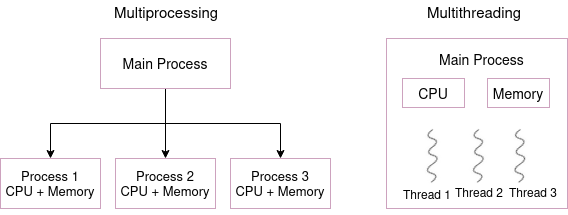

In [10]:
import threading
import time
import cotyledon

class PrinterService(cotyledon.Service):
    name = "printer"

    def __init__(self, worker_id):
        super(PrinterService, self).__init__(worker_id)
        self._shutdown = threading.Event()

    def run(self):
        while not self._shutdown.is_set():
            print("Doing stuff")
            time.sleep(1)

    def terminate(self):
        self._shutdown.set()

# Create a manager
manager = cotyledon.ServiceManager()
# Add 2 PrinterService to run
manager.add(PrinterService, 2)
# Run all of that
manager.run()

Doing stuff
Doing stuff
Doing stuffDoing stuff

Doing stuff
Doing stuff
Doing stuffDoing stuff

Doing stuff
Doing stuff
Doing stuff
Doing stuff
Doing stuff
Doing stuff


: 

In [1]:
import multiprocessing
import time
import cotyledon

class Manager(cotyledon.ServiceManager):
    def __init__(self):
        super(Manager, self).__init__()
        queue = multiprocessing.Manager().Queue()
        self.add(ProducerService, args=(queue,))
        self.add(PrinterService, args=(queue,), workers=2)

class ProducerService(cotyledon.Service):
    def __init__(self, worker_id, queue):
        super(ProducerService, self).__init__(worker_id)
        self.queue = queue

    def run(self):
        i = 0
        while True:
            self.queue.put(i)
            i += 1
            time.sleep(1)

class PrinterService(cotyledon.Service):
    name = "printer"

    def __init__(self, worker_id, queue):
        super(PrinterService, self).__init__(worker_id)
        self.queue = queue

    def run(self):
        while True:
            job = self.queue.get(block=True)
            print("I am Worker: %d PID: %d and I print %s"
                  % (self.worker_id, self.pid, job))

Manager().run()

I am Worker: 0 PID: 128086 and I print 0
I am Worker: 0 PID: 128086 and I print 1
I am Worker: 1 PID: 128095 and I print 2
I am Worker: 0 PID: 128086 and I print 3
I am Worker: 1 PID: 128095 and I print 4
I am Worker: 0 PID: 128086 and I print 5
I am Worker: 1 PID: 128095 and I print 6
I am Worker: 0 PID: 128086 and I print 7
I am Worker: 1 PID: 128095 and I print 8
I am Worker: 0 PID: 128086 and I print 9
I am Worker: 1 PID: 128095 and I print 10
I am Worker: 0 PID: 128086 and I print 11
I am Worker: 1 PID: 128095 and I print 12
I am Worker: 0 PID: 128086 and I print 13


: 

### Use Case

In [1]:
import random
import threading

mylist = [random.randint(1, 100000000) for i in range(1000000)]
mins = []

def calc_min(li):
    minimum = li[0]
    for x in li:
        if x < minimum:
            minimum = x
    mins.append(minimum)

l1 = mylist[:len(mylist) // 2]
l2 = mylist[len(mylist) // 2:]

q1 = l1[:len(l1)//2]
q2 = l1[len(l1)//2 :]
q3 = l2[: len(l2)//2]
q4 = l2[len(l2)//2 :]

workers = []
workers.append(threading.Thread(target=calc_min, args=(q1,)))
workers.append(threading.Thread(target=calc_min, args=(q2,)))
workers.append(threading.Thread(target=calc_min, args=(q3,)))
workers.append(threading.Thread(target=calc_min, args=(q4,)))

for worker in workers:
    worker.start()
for worker in workers:
    worker.join()

print("Global Minimum: ", min(mins))

Global Minimum:  18


## 事件循环（消息调度）

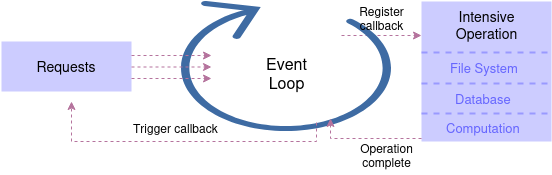

**一个简单的示例**

```python
while True: message = get_message() if message == quit: break
  process_message(message)
```

### 阻塞事件

In [ ]:
import socket

s = socket.create_connection(("httpbin.org", 80))
s.send(b"GET /delay/5 HTTP/1.1\r\nHost: httpbin.org\r\n\r\n") # 5秒后返回
buf = s.recv(1024)
print(buf)

b'HTTP/1.1 200 OK\r\nDate: Wed, 17 Sep 2025 17:08:38 GMT\r\nContent-Type: application/json\r\nContent-Length: 246\r\nConnection: keep-alive\r\nServer: gunicorn/19.9.0\r\nAccess-Control-Allow-Origin: *\r\nAccess-Control-Allow-Credentials: true\r\n\r\n{\n  "args": {}, \n  "data": "", \n  "files": {}, \n  "form": {}, \n  "headers": {\n    "Host": "httpbin.org", \n    "X-Amzn-Trace-Id": "Root=1-68caeb10-72af254333bc95091a976def"\n  }, \n  "origin": "49.65.79.58", \n  "url": "http://httpbin.org/delay/5"\n}\n'


In [ ]:
import socket

s = socket.create_connection(("httpbin.org", 80))
s.setblocking(False) # socket设置为异步模式
s.send(b"GET /delay/5 HTTP/1.1\r\nHost: httpbin.org\r\n\r\n")
buf = s.recv(1024) # 没有获得消息会报错
print(buf)


BlockingIOError: [Errno 11] Resource temporarily unavailable

In [ ]:
import select
import socket

s = socket.create_connection(("httpbin.org", 80))
s.setblocking(False)
s.send(b"GET /delay/1 HTTP/1.1\r\nHost: httpbin.org\r\n\r\n")
while True:
    ready_to_read, ready_to_write, in_error = select.select(  # select类似linux的epoll，python还提供了asyncio来替代
        [s], [], [])
    if s in ready_to_read:
        buf = s.recv(1024)
        print(buf)
        break

b'HTTP/1.1 200 OK\r\nDate: Wed, 17 Sep 2025 17:10:51 GMT\r\nContent-Type: application/json\r\nContent-Length: 246\r\nConnection: keep-alive\r\nServer: gunicorn/19.9.0\r\nAccess-Control-Allow-Origin: *\r\nAccess-Control-Allow-Credentials: true\r\n\r\n'


### asyncio处理阻塞调用

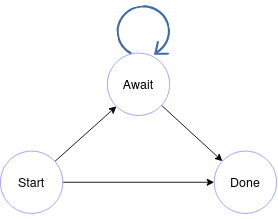

In [9]:
import asyncio

async def hello_world():
    print("hello world!")
    return 42

hello_world_coroutine = hello_world()
print(hello_world_coroutine)

print("entering event loop")
result = await hello_world_coroutine
print(result)

<coroutine object hello_world at 0x72ee765d7040>
entering event loop
hello world!
42


/tmp/ipykernel_128164/1432970496.py:7: RuntimeWarning: coroutine 'hello_world' was never awaited
  hello_world_coroutine = hello_world()


In [8]:
import asyncio

async def add_42(number):
    print("Adding 42")
    return 42 + number

async def hello_world():
    print("hello world!")
    result = await add_42(23)
    return result

result = await hello_world()
print(result)

hello world!
Adding 42
65


In [10]:
import asyncio

async def hello_world():
    print("hello world!")

async def hello_python():
    print("hello Python!")
    await asyncio.sleep(0.1)

event_loop = asyncio.get_event_loop()
try:
    result = event_loop.run_until_complete(asyncio.gather(
        hello_world(),
        hello_python(),
    ))
    print(result)
finally:
    event_loop.close()

RuntimeError: Cannot close a running event loop

hello world!
hello Python!


In [11]:
import aiohttp
import asyncio

async def get(url):
    async with aiohttp.ClientSession() as session:
        async with session.get(url) as response:
            return response

loop = asyncio.get_event_loop()
coroutines = [get("http://example.com") for _ in range(8)]
results = loop.run_until_complete(asyncio.gather(*coroutines))

print("Results: %s" % results)

RuntimeError: This event loop is already running

### Client and Server

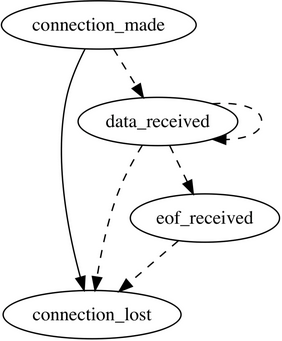

In [14]:
import asyncio
import time

SERVER_ADDRESS = ('0.0.0.0', 1234)

class YellEchoServer(asyncio.Protocol):
    def __init__(self, stats):
        self.stats = stats
        self.stats['started at'] = time.time()

    def connection_made(self, transport):
        self.transport = transport
        self.stats['connections'] += 1

    def data_received(self, data):
        self.transport.write(data.upper())
        self.stats['messages sent'] += 1

stats = {
    "connections": 0,
    "messages sent": 0,
}

async def start_server():
    loop = asyncio.get_running_loop()
    server = await loop.create_server(
        lambda: YellEchoServer(stats), *SERVER_ADDRESS)
    print(f"Serving on {SERVER_ADDRESS}")
    try:
        await server.serve_forever()
    except asyncio.CancelledError:
        pass
    finally:
        server.close()
        await server.wait_closed()
        ran_for = time.time() - stats['started at']
        print("Server ran for: %.2f seconds" % ran_for)
        print("Connections: %d" % stats['connections'])
        print("Messages sent: %d" % stats['messages sent'])
        print("Messages sent per second: %.2f"
              % (stats['messages sent'] / ran_for))

# In Jupyter, use asyncio.create_task to start the server
task = asyncio.create_task(start_server())

Serving on ('0.0.0.0', 1234)


In [16]:
import asyncio

SERVER_ADDRESS = ('0.0.0.0', 1234)

class EchoClientProtocol(asyncio.Protocol):
    def __init__(self, message, loop):
        self.message = message
        self.loop = loop

    def talk(self):
        self.transport.write(self.message)

    def connection_made(self, transport):
        self.transport = transport
        self.talk()

    def data_received(self, data):
        self.talk()

    def connection_lost(self, exc):
        self.loop.stop()

async def run_client():
    loop = asyncio.get_running_loop()
    await loop.create_connection(
        lambda: EchoClientProtocol(b'Hello World!', loop),
        *SERVER_ADDRESS)

await run_client()

### Use case

In [19]:
## Import other libraries if you want (asyncio and aiohttp are supported)
import time
import aiohttp
import asyncio

urls = ["http://educative.io", "http://educative.io/blog", "http://youtube.com"]

async def get(url):
    async with aiohttp.ClientSession() as session:
        async with session.get(url) as response:
            return response

loop = asyncio.get_event_loop()

coroutines = []

for URL in urls:
    coroutines.append(get(url=URL))

start_time = time.time()
results = await asyncio.gather(*coroutines)
print("--- %s milliseconds ---" % ((time.time() - start_time)*1000))

print("Results: %s" % results)

ConnectionTimeoutError: Connection timeout to host http://youtube.com

## 函数式编程

- map
- filter
- next
- first
- itertools

### map(function, iterable)

map(function, iterable) 将function 应用于 iterable 中的每个项目，并返回 Python 2 中的列表或 Python 3 中的可迭代 map 对象

In [20]:
print(map(lambda x: x + 'bzz!', ['I think', 'I\'m good']))

## map wrapped in a list to print the list
print(list(map(lambda x: x + 'bzz!', ['I think', 'I\'m good'])))

['I thinkbzz!', "I'm goodbzz!"]


### filter(function or None, iterable) 

filter(function or None, iterable) 根据function 返回的结果过滤iterable中的项目，并返回 Python 2 中的列表或更高版本（Python 3 中的可迭代 filter 对象）

In [21]:
print( filter(lambda x: x.startswith('I '), ['I think', 'I\'m good']) )

## filter wrapped in a list to print
print( list(filter(lambda x: x.startswith('I '), ['I think', 'I\'m good'])) )

['I think']


### enumerate(iterable[, start])

enumerate(iterable[, start]) 返回一个可迭代的枚举对象，该对象生成一个元组序列，每个元组由一个整数索引（如果提供了 start 则从 start 开始）和 iterable 中对应的项组成。当你需要编写引用数组索引的代码时，它非常有用。

In [22]:
mylist = [1, 2, 3]
for i, item in enumerate(mylist):
    print('Item %d: %s' % (i, item))

Item 0: 1
Item 1: 2
Item 2: 3


### sorted(iterable, key=None, reverse=False) 
sorted(iterable, key=None, reverse=False) 返回可迭代对象的排序版本。key 允许您提供一个函数，该函数返回要排序的值。

In [23]:
print( sorted([10, 5, 20, 30, 25, -5]) ) 

[-5, 5, 10, 20, 25, 30]


### any(iterable) 和 all(iterable)

In [24]:
mylist = [0, 1, 3, -1]
if all(map(lambda x: x > 0, mylist)):
  print('All items are greater than 0')
if any(map(lambda x: x > 0, mylist)):
  print('At least one item is greater than 0')

At least one item is greater than 0


### zip(iter1 [,iter2 [...]]) 
zip(iter1 [,iter2 [...]]) 函数接受多个序列并将它们组合成元组。当你需要将键列表和值列表组合成字典时，它非常有用。

In [25]:
keys = ['foobar', 'barzz', 'ba!']

print(map(len, keys))

print(zip(keys, map(len, keys)))

print(list(zip(keys, map(len, keys))))

print(dict(zip(keys, map(len, keys))))

[('foobar', 6), ('barzz', 5), ('ba!', 3)]
{'foobar': 6, 'barzz': 5, 'ba!': 3}


In [26]:
def compute(numbers):
    ### `filter` function filters the number that are smaller than 50 and then the
    ### `map` applies the multiplication operator on each of the filtered number.
    ###  Finally, the `sum` function calculates the sum of the squared numbers in the list
    return sum(list( map(lambda x: x*x , filter(lambda x: x < 50, numbers)))) 

## 基于队列的分发

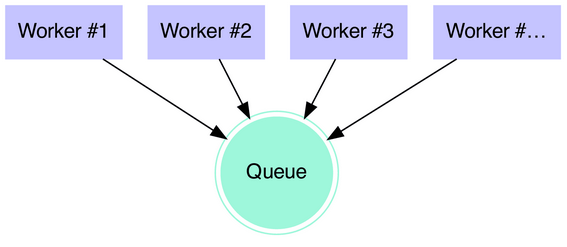

### RQ

### Celery

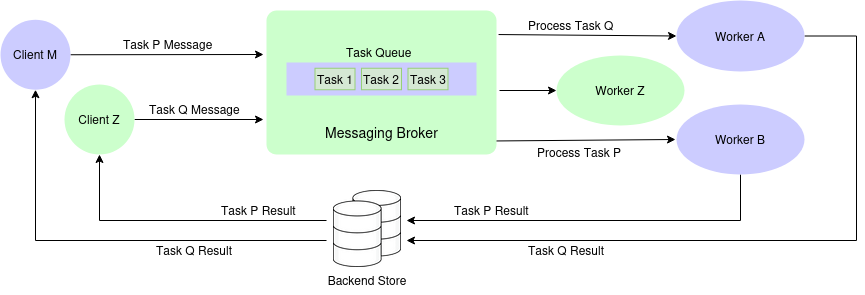

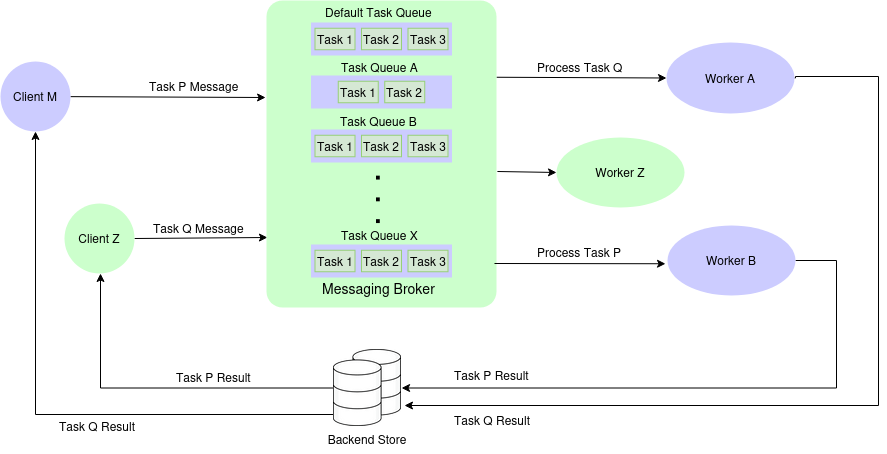


### Demo

Q:假设你有一堆文档，你想统计所有单词在这些文档中出现的频率。这是一个繁重的任务，所以你需要使用基于队列的系统 celery 以及 redis 的代理和后端。

In [27]:
import celery

app = celery.Celery('celery-test',
                    broker='redis://localhost',
                    backend='redis://localhost')

@app.task
def getWordCount(text):
    wordlist = text.split(' ')
    dict = {}
    for word in wordlist:
        if word not in dict.keys():
            dict[word] = 1
        else:
            dict[word] += 1
    return dict

if __name__ == '__main__':
    texts = ["Pickle in Python is primarily used in serializing and deserializing a Python object structure. In other words, it's the process of converting a Python object into a byte stream to store it in a file/database, maintain program state across sessions, or transport data over the network.", 
             "In some countries (e.g., the United States and Canada), essays have become a major part of formal education.",
             "Essays belong to a literary species whose extreme variability can be studied most effectively within a three-poled frame of reference"]

    results = []
    for text in texts:
        results.append( getWordCount.delay(text))

    for result in results:
        print("Task state: %s" % result.state)
        print("Result: %s" % result.get())
        print("Task state: %s" % result.state)



KeyboardInterrupt: 

## 面向故障设计

### 简单重试

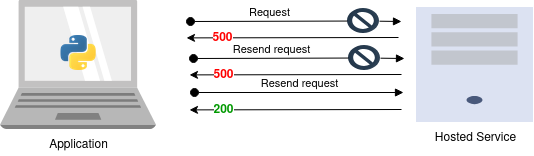

```python
while True:
  try:
    do_something()
  except:
    pass
  else:
    break
```

### tenacity

In [28]:
import tenacity
import random

def do_something():
    if random.random() > 0.0002:
        print("Failure")
        raise RuntimeError
    print("Success")
    return True

@tenacity.retry(wait=tenacity.wait_fixed(1),
                stop=tenacity.stop_after_delay(60),
                retry=(tenacity.retry_if_exception_type(RuntimeError) |
                       tenacity.retry_if_result(
                           lambda result: result is None)))
def do_something_and_retry():
    return do_something()

do_something_and_retry()

Failure
Failure
Failure
Failure
Failure
Failure
Failure
Failure
Failure
Failure
Failure
Failure
Failure
Failure
Failure
Failure
Failure
Failure
Failure
Failure
Failure
Failure
Failure
Failure
Failure
Failure


KeyboardInterrupt: 

### Demo

In [30]:
import tenacity
from random import randint

password = randint(10, 99)

def crackPassworrd():
    to_check = randint(10, 99)
    if password != to_check:
        print("No luck yet with: ", to_check)
        raise RuntimeError
    print("Password Cracked!!! - ", to_check)

@tenacity.retry(wait=tenacity.wait_fixed(1))
def do_something_and_retry():
    crackPassworrd()

do_something_and_retry()


No luck yet with:  81
No luck yet with:  62
No luck yet with:  57
No luck yet with:  14
No luck yet with:  52
No luck yet with:  37
No luck yet with:  65
No luck yet with:  49
No luck yet with:  24
No luck yet with:  66
No luck yet with:  50
No luck yet with:  41
No luck yet with:  62
No luck yet with:  98
No luck yet with:  85
No luck yet with:  32
No luck yet with:  20
No luck yet with:  61
No luck yet with:  97
No luck yet with:  23
No luck yet with:  97
No luck yet with:  55
No luck yet with:  79
No luck yet with:  96
No luck yet with:  76
No luck yet with:  73
No luck yet with:  58
No luck yet with:  13
No luck yet with:  10
No luck yet with:  61
No luck yet with:  21
No luck yet with:  65
No luck yet with:  69
No luck yet with:  32
No luck yet with:  82
No luck yet with:  39
No luck yet with:  42
No luck yet with:  26
No luck yet with:  28
No luck yet with:  22
No luck yet with:  21
No luck yet with:  44
No luck yet with:  44
No luck yet with:  59
No luck yet with:  71
No luck ye

## Create a Web Crawler

In [2]:
import celery
import requests
import tenacity

app = celery.Celery('celery-proj', broker='redis://localhost', backend='redis://localhost')

def do_something(url_to_crawl):
    dic = {}
    r = requests.get(url = url_to_crawl)
    if r.status_code != 200:
        raise RuntimeError
    text = r.text
    dic['data'] = text
    dic['status_code'] = r.status_code
    return dic

@app.task
def getURL(url_to_crawl):
    @tenacity.retry(wait=tenacity.wait_fixed(5), stop=tenacity.stop_after_attempt(3))
    def do_something_and_retry(url_to_crawl):
        return do_something(url_to_crawl)
    return do_something_and_retry(url_to_crawl=url_to_crawl)

if __name__ == '__main__':
    urls = ["http://educative.io", "http://example.org/", "http://example.com"]

    results = []
    for url in urls:
        results.append(getURL.delay(url))
    
    for result in results:
        print("Task state: %s" % result.state)
        print("Result: %s" % result.get())
        print("Task state: %s" % result.state)

OperationalError: Error 111 connecting to localhost:6379. Connection refused.

## 锁管理

### 线程锁管理

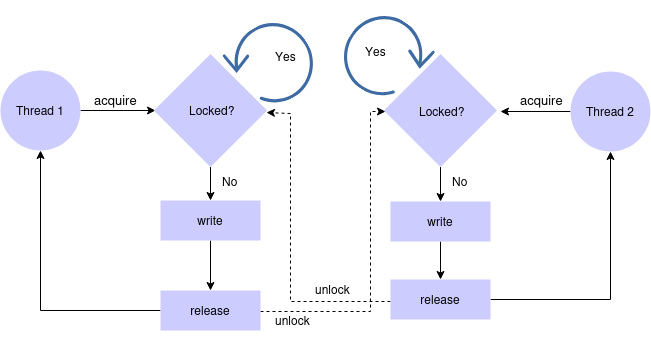